# Exploración de los datos

El achivo shirts.txt contiene los 8 moldes posibles, y cuántas repeticiones deben darse de cada uno  

## Extracción de moldes 

In [52]:
from pathlib import Path

import pandas as pd

In [53]:
# Busco la raíz del proyecto.
# Esto permite ejecutar el notebook tanto desde AE/ como desde AE/notebooks/.

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "shirts.txt"

print("Raíz del proyecto:", PROJECT_ROOT)
print("Ruta del dataset:", DATA_PATH)
print("¿Existe el archivo?:", DATA_PATH.exists())

Raíz del proyecto: c:\Users\pc\OneDrive\Escritorio\EIA\AE
Ruta del dataset: c:\Users\pc\OneDrive\Escritorio\EIA\AE\data\raw\shirts.txt
¿Existe el archivo?: True


In [54]:
with DATA_PATH.open("r", encoding="utf-8") as file:
    raw_text = file.read()

print(raw_text[:800])

PIECE 1
QUANTITY
8
NUMBER OF VERTICES
8
VERTICES (X,Y)
 0   0
 7   1
 7   5
 0   7
-1   5
-1   4
-2   3
-1   2

PIECE 2
QUANTITY
8
NUMBER OF VERTICES
10
VERTICES (X,Y)
 0   0
11   0
12   2
11   3
11   5
10   6
 6   5
 3   6
 0   5
-1   3

PIECE 3
QUANTITY
8
NUMBER OF VERTICES
10
VERTICES (X,Y)
 0   0
 3   0
 3  -1
 5   0
 8   0
11  -1
12   4
11   8
 7   7
 0   7

PIECE 4
QUANTITY
15
NUMBER OF VERTICES
5
VERTICES (X,Y)
 0   0
 4   0
 4   2
 3   3
 0   3

PIECE 5
QUANTITY
15
NUMBER OF VERTICES
4
VERTICES (X,Y)
 0   0
 8   0
 7   1
 1   1

PIECE 6
QUANTITY
15
NUMBER OF VERTICES
4
VERTICES (X,Y)
 0   0
 4   0
 4   1
 0   1

PIECE 7
QUANTITY
15
NUMBER OF VERTICES
4
VERTICES (X,Y)
 0   0
 3   0
 3   1
 0   1

PIECE 8
QUANTITY
15
NUMBER OF VERTICES
8
VERTICES (X,Y)
 0   0
 8   0
 8   2
 6   2
 4 


In [55]:
raw_lines = raw_text.splitlines()

print("Cantidad total de líneas:", len(raw_lines))
print("\nPrimeras 20 líneas:")

for line in raw_lines[:20]:
    print(repr(line))

Cantidad total de líneas: 108

Primeras 20 líneas:
'PIECE 1'
'QUANTITY'
'8'
'NUMBER OF VERTICES'
'8'
'VERTICES (X,Y)'
' 0   0'
' 7   1'
' 7   5'
' 0   7'
'-1   5'
'-1   4'
'-2   3'
'-1   2'
''
'PIECE 2'
'QUANTITY'
'8'
'NUMBER OF VERTICES'
'10'


In [56]:
lines = [
    line.strip()
    for line in raw_lines
    if line.strip()
]

print("Cantidad de líneas no vacías:", len(lines))
print("\nPrimeras 20 líneas procesadas:")

for line in lines[:20]:
    print(line)
    

Cantidad de líneas no vacías: 101

Primeras 20 líneas procesadas:
PIECE 1
QUANTITY
8
NUMBER OF VERTICES
8
VERTICES (X,Y)
0   0
7   1
7   5
0   7
-1   5
-1   4
-2   3
-1   2
PIECE 2
QUANTITY
8
NUMBER OF VERTICES
10
VERTICES (X,Y)


In [57]:
def parse_shirts_txt(path: Path) -> list[dict]:
    """
    Lee el archivo shirts.txt y devuelve una lista de tipos de piezas.

    Cada elemento contiene:
    - piece_type: número del tipo de pieza
    - quantity: cantidad de copias
    - n_vertices: cantidad de vértices
    - vertices: lista de coordenadas (x, y)
    """

    with path.open("r", encoding="utf-8") as file:
        lines = [
            line.strip()
            for line in file
            if line.strip()
        ]

    piece_types = []
    index = 0

    while index < len(lines):

        # Ejemplo: "PIECE 1"
        piece_line = lines[index]

        if not piece_line.startswith("PIECE "):
            raise ValueError(
                f"Se esperaba una línea 'PIECE', "
                f"pero se encontró: {piece_line}"
            )

        piece_type = int(piece_line.split()[1])
        index += 1

        # QUANTITY
        if lines[index] != "QUANTITY":
            raise ValueError(
                f"Se esperaba 'QUANTITY' para la pieza {piece_type}."
            )

        quantity = int(lines[index + 1])
        index += 2

        # NUMBER OF VERTICES
        if lines[index] != "NUMBER OF VERTICES":
            raise ValueError(
                f"Se esperaba 'NUMBER OF VERTICES' "
                f"para la pieza {piece_type}."
            )

        n_vertices = int(lines[index + 1])
        index += 2

        # VERTICES (X,Y)
        if lines[index] != "VERTICES (X,Y)":
            raise ValueError(
                f"Se esperaba 'VERTICES (X,Y)' "
                f"para la pieza {piece_type}."
            )

        index += 1

        vertices = []

        for _ in range(n_vertices):
            x_text, y_text = lines[index].split()

            vertices.append(
                (float(x_text), float(y_text))
            )

            index += 1

        piece_types.append(
            {
                "piece_type": piece_type,
                "quantity": quantity,
                "n_vertices": n_vertices,
                "vertices": vertices,
            }
        )

    return piece_types

In [58]:
piece_types = parse_shirts_txt(DATA_PATH)

print("Cantidad de tipos encontrados:", len(piece_types))

Cantidad de tipos encontrados: 8


In [59]:
piece_types[0]

{'piece_type': 1,
 'quantity': 8,
 'n_vertices': 8,
 'vertices': [(0.0, 0.0),
  (7.0, 1.0),
  (7.0, 5.0),
  (0.0, 7.0),
  (-1.0, 5.0),
  (-1.0, 4.0),
  (-2.0, 3.0),
  (-1.0, 2.0)]}

In [60]:
summary_df = pd.DataFrame(
    [
        {
            "tipo": piece["piece_type"],
            "cantidad": piece["quantity"],
            "numero_vertices": piece["n_vertices"],
        }
        for piece in piece_types
    ]
)

summary_df

,tipo,cantidad,numero_vertices
0,1,8,8
1,2,8,10
2,3,8,10
3,4,15,5
4,5,15,4
5,6,15,4
6,7,15,4
7,8,15,8


In [61]:
total_pieces = summary_df["cantidad"].sum()

print("Cantidad total de piezas:", total_pieces)

Cantidad total de piezas: 99


## Gráfico de moldes

Los moldes son polígonos varios.

In [62]:
import numpy as np
import matplotlib.pyplot as plt

from shapely.geometry import Polygon
from shapely.affinity import translate
from shapely.validation import explain_validity

In [63]:
for piece in piece_types:
    piece["polygon_original"] = Polygon(piece["vertices"])

print("Polígonos creados:", len(piece_types))

Polígonos creados: 8


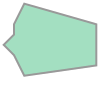

In [64]:
piece_types[0]["polygon_original"]

In [65]:
polygon_1 = piece_types[0]["polygon_original"]

print("Tipo geométrico:", polygon_1.geom_type)
print("Área:", polygon_1.area)
print("Perímetro:", polygon_1.length)
print("Límites:", polygon_1.bounds)
print("¿Es válido?:", polygon_1.is_valid)

Tipo geométrico: Polygon
Área: 44.5
Perímetro: 26.651740780891764
Límites: (-2.0, 0.0, 7.0, 7.0)
¿Es válido?: True


In [66]:
geometry_rows = []

for piece in piece_types:
    polygon = piece["polygon_original"]

    min_x, min_y, max_x, max_y = polygon.bounds

    geometry_rows.append(
        {
            "tipo": piece["piece_type"],
            "cantidad": piece["quantity"],
            "vertices": piece["n_vertices"],
            "area_unitaria": polygon.area,
            "perimetro": polygon.length,
            "min_x": min_x,
            "min_y": min_y,
            "max_x": max_x,
            "max_y": max_y,
            "ancho_envolvente": max_x - min_x,
            "alto_envolvente": max_y - min_y,
            "geometria_valida": polygon.is_valid,
            "area_total_tipo": polygon.area * piece["quantity"],
        }
    )

geometry_df = pd.DataFrame(geometry_rows)

geometry_df.round(2)

,tipo,cantidad,vertices,area_unitaria,perimetro,min_x,min_y,max_x,max_y,ancho_envolvente,alto_envolvente,geometria_valida,area_total_tipo
0,1,8,8,44.5,26.65,-2.0,0.0,7.0,7.0,9.0,7.0,True,356.0
1,2,8,10,64.5,33.91,-1.0,0.0,12.0,6.0,13.0,6.0,True,516.0
2,3,8,10,86.0,39.74,0.0,-1.0,12.0,8.0,12.0,9.0,True,688.0
3,4,15,5,11.5,13.41,0.0,0.0,4.0,3.0,4.0,3.0,True,172.5
4,5,15,4,7.0,16.83,0.0,0.0,8.0,1.0,8.0,1.0,True,105.0
5,6,15,4,4.0,10.00,0.0,0.0,4.0,1.0,4.0,1.0,True,60.0
6,7,15,4,3.0,8.00,0.0,0.0,3.0,1.0,3.0,1.0,True,45.0
7,8,15,8,14.5,21.89,-1.0,0.0,8.0,2.0,9.0,2.0,True,217.5


In [67]:
for piece in piece_types:
    polygon = piece["polygon_original"]

    print(
        f"Pieza {piece['piece_type']}: "
        f"válida={polygon.is_valid}, "
        f"área={polygon.area}"
    )

    if not polygon.is_valid:
        print("  Problema:", explain_validity(polygon))
        

Pieza 1: válida=True, área=44.5
Pieza 2: válida=True, área=64.5
Pieza 3: válida=True, área=86.0
Pieza 4: válida=True, área=11.5
Pieza 5: válida=True, área=7.0
Pieza 6: válida=True, área=4.0
Pieza 7: válida=True, área=3.0
Pieza 8: válida=True, área=14.5


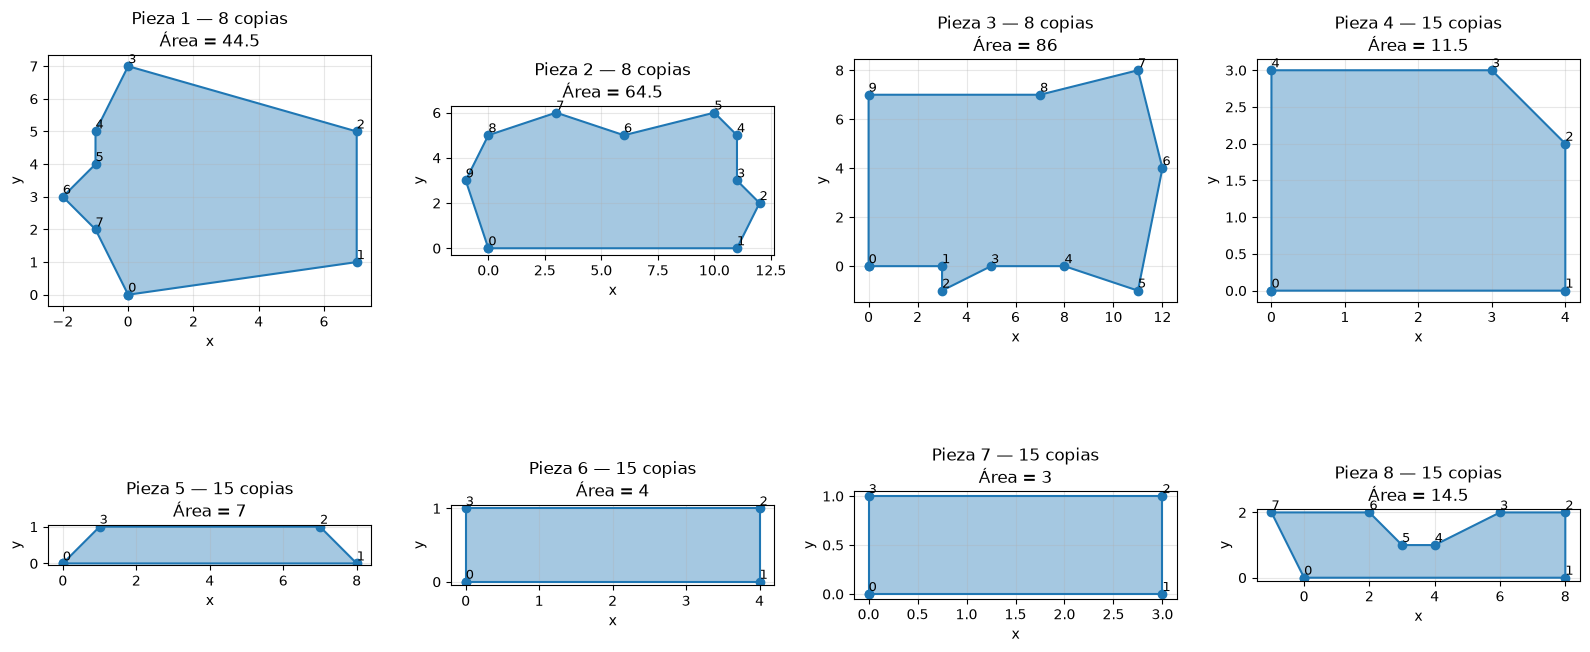

In [68]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(16, 8)
)

axes = axes.flatten()

for ax, piece in zip(axes, piece_types):
    polygon = piece["polygon_original"]

    x, y = polygon.exterior.xy

    ax.fill(x, y, alpha=0.4)
    ax.plot(x, y, marker="o")

    # Número de cada vértice.
    for vertex_index, (vertex_x, vertex_y) in enumerate(
        piece["vertices"]
    ):
        ax.text(
            vertex_x,
            vertex_y,
            str(vertex_index),
            fontsize=9,
            ha="left",
            va="bottom"
        )

    ax.set_title(
        f"Pieza {piece['piece_type']} — "
        f"{piece['quantity']} copias\n"
        f"Área = {polygon.area:g}"
    )

    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

In [69]:
def normalize_polygon(polygon: Polygon) -> Polygon:
    """
    Traslada un polígono para que su esquina inferior izquierda
    del rectángulo envolvente quede en (0, 0).
    """

    min_x, min_y, _, _ = polygon.bounds

    return translate(
        polygon,
        xoff=-min_x,
        yoff=-min_y
    )

In [70]:
for piece in piece_types:
    original = piece["polygon_original"]
    normalized = normalize_polygon(original)

    piece["polygon_normalized"] = normalized

In [71]:
normalization_rows = []

for piece in piece_types:
    original = piece["polygon_original"]
    normalized = piece["polygon_normalized"]

    normalization_rows.append(
        {
            "tipo": piece["piece_type"],
            "limites_originales": original.bounds,
            "limites_normalizados": normalized.bounds,
            "area_original": original.area,
            "area_normalizada": normalized.area,
        }
    )

normalization_df = pd.DataFrame(normalization_rows)

normalization_df

,tipo,limites_originales,limites_normalizados,area_original,area_normalizada
0,1,"(-2.0, 0.0, 7.0, 7.0)","(0.0, 0.0, 9.0, 7.0)",44.5,44.5
1,2,"(-1.0, 0.0, 12.0, 6.0)","(0.0, 0.0, 13.0, 6.0)",64.5,64.5
2,3,"(0.0, -1.0, 12.0, 8.0)","(0.0, 0.0, 12.0, 9.0)",86.0,86.0
3,4,"(0.0, 0.0, 4.0, 3.0)","(0.0, 0.0, 4.0, 3.0)",11.5,11.5
4,5,"(0.0, 0.0, 8.0, 1.0)","(0.0, 0.0, 8.0, 1.0)",7.0,7.0
5,6,"(0.0, 0.0, 4.0, 1.0)","(0.0, 0.0, 4.0, 1.0)",4.0,4.0
6,7,"(0.0, 0.0, 3.0, 1.0)","(0.0, 0.0, 3.0, 1.0)",3.0,3.0
7,8,"(-1.0, 0.0, 8.0, 2.0)","(0.0, 0.0, 9.0, 2.0)",14.5,14.5


In [72]:
total_piece_area = sum(
    piece["polygon_original"].area * piece["quantity"]
    for piece in piece_types
)

print("Área total de las 99 piezas:", total_piece_area)

Área total de las 99 piezas: 2160.0


In [73]:
geometry_df[
    ["tipo", "cantidad", "area_unitaria", "area_total_tipo"]
].sort_values(
    by="area_total_tipo",
    ascending=False
).round(2)

,tipo,cantidad,area_unitaria,area_total_tipo
2,3,8,86.0,688.0
1,2,8,64.5,516.0
0,1,8,44.5,356.0
7,8,15,14.5,217.5
3,4,15,11.5,172.5
4,5,15,7.0,105.0
5,6,15,4.0,60.0
6,7,15,3.0,45.0


## Exploro acomodos en tela 

In [74]:
FABRIC_WIDTH = 40

theoretical_min_length = total_piece_area / FABRIC_WIDTH

print("Ancho de la tela:", FABRIC_WIDTH)
print("Área total:", total_piece_area)
print(
    "Longitud mínima teórica:",
    theoretical_min_length
)

Ancho de la tela: 40
Área total: 2160.0
Longitud mínima teórica: 54.0


In [75]:
def material_utilization(
    used_length: float,
    fabric_width: float = FABRIC_WIDTH
) -> float:
    """
    Calcula la proporción de tela ocupada por las piezas.
    """

    used_rectangle_area = used_length * fabric_width

    return total_piece_area / used_rectangle_area

In [76]:
for length in [54, 60, 65, 70, 80]:
    utilization = material_utilization(length)

    print(
        f"Longitud {length:>3}: "
        f"aprovechamiento = {utilization:.2%}"
    )

Longitud  54: aprovechamiento = 100.00%
Longitud  60: aprovechamiento = 90.00%
Longitud  65: aprovechamiento = 83.08%
Longitud  70: aprovechamiento = 77.14%
Longitud  80: aprovechamiento = 67.50%


# Resumen hasta ahora

* Existen 8 tipos de moldes
* Hay 99 piezas en total
* El área total es 2160 u^2
* Si la tela tiene 40 u de ancho, ninguna solución puede usar menos de 54 unidades de longitud
* las piezas 1, 2 y 3 concentran la mayor parte del material


# Exploración de estructura NFP del XML


In [77]:
from pathlib import Path
import xml.etree.ElementTree as ET

import pandas as pd
import matplotlib.pyplot as plt

from shapely.geometry import Polygon

In [78]:
# Si el notebook se ejecuta desde AE/notebooks,
# retrocedemos un nivel para encontrar la raíz del proyecto.

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

XML_PATH = PROJECT_ROOT / "data" / "raw" / "shirts.xml"

print("Ruta del XML:", XML_PATH)
print("¿Existe?:", XML_PATH.exists())

Ruta del XML: c:\Users\pc\OneDrive\Escritorio\EIA\AE\data\raw\shirts.xml
¿Existe?: True


In [79]:
tree = ET.parse(XML_PATH)
xml_root = tree.getroot()

NS = {
    "n": "http://www.fe.up.pt/~esicup/nesting.xsd"
}

print("Etiqueta raíz:")
print(xml_root.tag)

Etiqueta raíz:
{http://www.fe.up.pt/~esicup/nesting.xsd}nesting


In [80]:
dataset_metadata = {
    "nombre": xml_root.findtext("n:name", namespaces=NS),
    "autor": xml_root.findtext("n:author", namespaces=NS),
    "fecha": xml_root.findtext("n:date", namespaces=NS),
    "orientacion_vertices": xml_root.findtext(
        "n:verticesOrientation",
        namespaces=NS,
    ),
    "origen_coordenadas": xml_root.findtext(
        "n:coordinatesOrigin",
        namespaces=NS,
    ),
    "descripcion": xml_root.findtext(
        "n:description",
        namespaces=NS,
    ),
}

for key, value in dataset_metadata.items():
    print(f"{key}: {value}")

nombre: Shirts
autor: OLIVEIRA/GOMES/FERREIRA and DOWSLAND/DOWSLAND/BENNELL
fecha: 2006/06/13
orientacion_vertices: clockwise
origen_coordenadas: up-left
descripcion: Data set from the textile industry, instance initially used in Dowsland K. A., Dowsland W. B. and Bennell J. A., 1998, "Jostling for position: local improvement for irregular cutting patterns", Journal of the Operational Research Society 49, 647-658, coordinates stated in Oliveira J. F., Gomes A. M. and Ferreira S., 2000, "A new constructive algorithm for nesting problems", OR Spectrum 22 (2), 263-284.


In [81]:
lot_element = xml_root.find(
    "n:problem/n:lot",
    NS,
)

piece_type_rows = []

for piece_element in lot_element.findall("n:piece", NS):
    piece_id = piece_element.attrib["id"]
    quantity = int(piece_element.attrib["quantity"])

    orientation_elements = piece_element.findall(
        "n:orientation/n:enumeration",
        NS,
    )

    orientations = [
        int(float(element.attrib["angle"]))
        for element in orientation_elements
    ]

    component_element = piece_element.find(
        "n:component",
        NS,
    )

    polygon_id = component_element.attrib["idPolygon"]

    piece_type_rows.append(
        {
            "piece_id": piece_id,
            "quantity": quantity,
            "polygon_id": polygon_id,
            "orientations": orientations,
        }
    )

xml_piece_types_df = pd.DataFrame(piece_type_rows)

xml_piece_types_df

,piece_id,quantity,polygon_id,orientations
0,piece0,8,polygon1,"[0, 180]"
1,piece1,8,polygon2,"[0, 180]"
2,piece2,8,polygon3,"[0, 180]"
3,piece3,15,polygon4,"[0, 180]"
4,piece4,15,polygon5,"[0, 180]"
5,piece5,15,polygon6,"[0, 180]"
6,piece6,15,polygon7,"[0, 180]"
7,piece7,15,polygon8,"[0, 180]"


In [82]:
total_pieces_xml = xml_piece_types_df["quantity"].sum()

print("Tipos de piezas:", len(xml_piece_types_df))
print("Cantidad total:", total_pieces_xml)
print(
    "Orientaciones observadas:",
    xml_piece_types_df["orientations"].tolist(),
)

Tipos de piezas: 8
Cantidad total: 99
Orientaciones observadas: [[0, 180], [0, 180], [0, 180], [0, 180], [0, 180], [0, 180], [0, 180], [0, 180]]


In [83]:
def polygon_element_to_vertices(
    polygon_element: ET.Element,
) -> list[tuple[float, float]]:
    """
    Reconstruye los vértices de un polígono XML.

    Los segmentos se ordenan por el atributo n.
    Se toma el punto inicial (x0, y0) de cada segmento.
    """

    segments = polygon_element.findall(
        "n:lines/n:segment",
        NS,
    )

    ordered_segments = sorted(
        segments,
        key=lambda segment: int(segment.attrib["n"]),
    )

    vertices = [
        (
            float(segment.attrib["x0"]),
            float(segment.attrib["y0"]),
        )
        for segment in ordered_segments
    ]

    return vertices

In [84]:
base_polygons = {}

for polygon_element in xml_root.findall(
    "n:polygons/n:polygon",
    NS,
):
    polygon_id = polygon_element.attrib["id"]

    # Excluimos por ahora nfpPolygon e ifpPolygon.
    if not polygon_id.startswith("polygon"):
        continue

    vertices = polygon_element_to_vertices(
        polygon_element
    )

    polygon = Polygon(vertices)

    base_polygons[polygon_id] = {
        "polygon_id": polygon_id,
        "n_vertices_declared": int(
            polygon_element.attrib["nVertices"]
        ),
        "vertices": vertices,
        "polygon": polygon,
    }

print("Polígonos base encontrados:", len(base_polygons))
print("IDs:", list(base_polygons))

Polígonos base encontrados: 9
IDs: ['polygon0', 'polygon1', 'polygon2', 'polygon3', 'polygon4', 'polygon5', 'polygon6', 'polygon7', 'polygon8']


In [85]:
board_polygon = base_polygons["polygon0"]["polygon"]

min_x, min_y, max_x, max_y = board_polygon.bounds

board_length = max_x - min_x
board_width = max_y - min_y

print("Límites del tablero:", board_polygon.bounds)
print("Longitud disponible:", board_length)
print("Ancho:", board_width)

Límites del tablero: (0.0, 0.0, 1000.0, 40.0)
Longitud disponible: 1000.0
Ancho: 40.0


In [86]:
xml_geometry_rows = []

for _, piece_row in xml_piece_types_df.iterrows():
    polygon_id = piece_row["polygon_id"]
    polygon_data = base_polygons[polygon_id]
    polygon = polygon_data["polygon"]

    min_x, min_y, max_x, max_y = polygon.bounds

    xml_geometry_rows.append(
        {
            "piece_id": piece_row["piece_id"],
            "polygon_id": polygon_id,
            "quantity": piece_row["quantity"],
            "orientations": piece_row["orientations"],
            "n_vertices": len(
                polygon_data["vertices"]
            ),
            "area": polygon.area,
            "width": max_x - min_x,
            "height": max_y - min_y,
            "valid": polygon.is_valid,
        }
    )

xml_geometry_df = pd.DataFrame(
    xml_geometry_rows
)

xml_geometry_df

,piece_id,polygon_id,quantity,orientations,n_vertices,area,width,height,valid
0,piece0,polygon1,8,"[0, 180]",8,44.5,9.0,7.0,True
1,piece1,polygon2,8,"[0, 180]",10,64.5,13.0,6.0,True
2,piece2,polygon3,8,"[0, 180]",10,86.0,12.0,9.0,True
3,piece3,polygon4,15,"[0, 180]",5,11.5,4.0,3.0,True
4,piece4,polygon5,15,"[0, 180]",4,7.0,8.0,1.0,True
5,piece5,polygon6,15,"[0, 180]",4,4.0,4.0,1.0,True
6,piece6,polygon7,15,"[0, 180]",4,3.0,3.0,1.0,True
7,piece7,polygon8,15,"[0, 180]",8,14.5,9.0,2.0,True


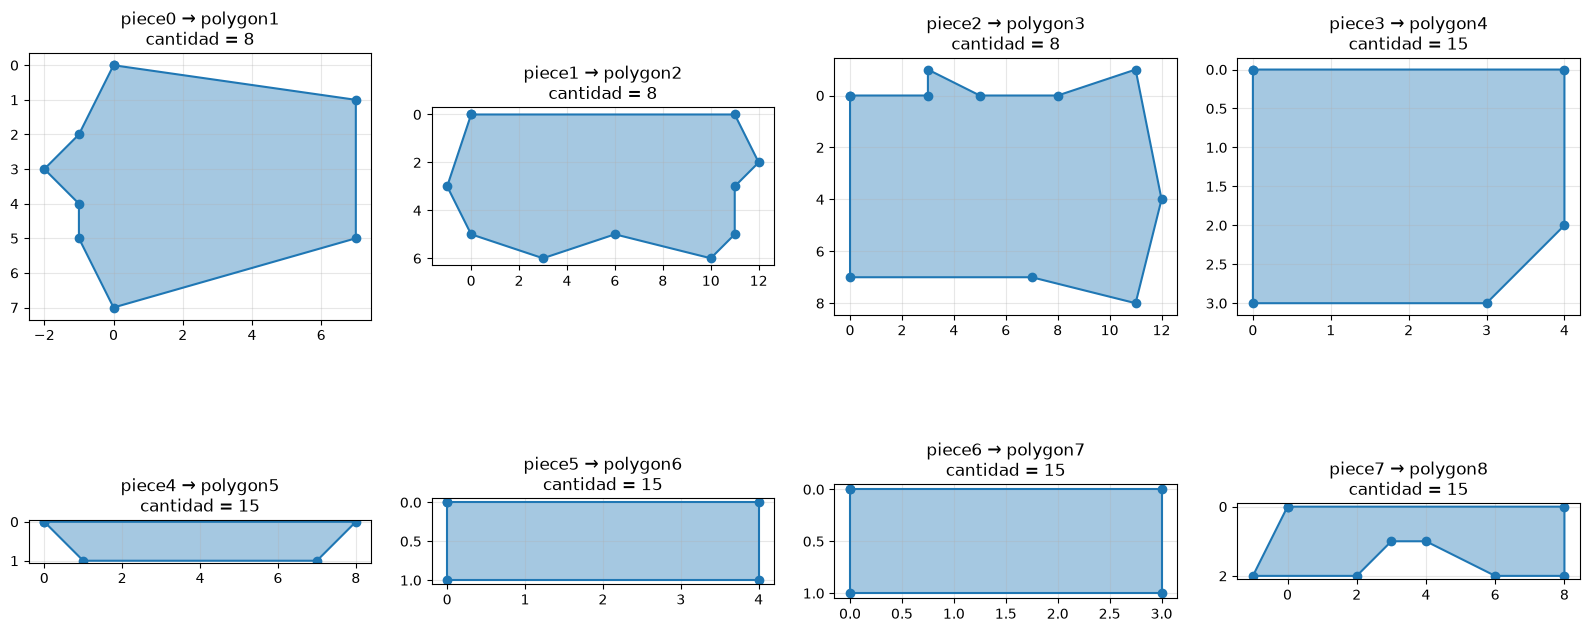

In [87]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8),
)

axes = axes.flatten()

for ax, (_, piece_row) in zip(
    axes,
    xml_piece_types_df.iterrows(),
):
    polygon_id = piece_row["polygon_id"]
    polygon = base_polygons[polygon_id]["polygon"]

    x, y = polygon.exterior.xy

    ax.fill(x, y, alpha=0.4)
    ax.plot(x, y, marker="o")

    ax.set_title(
        f"{piece_row['piece_id']} → {polygon_id}\n"
        f"cantidad = {piece_row['quantity']}"
    )

    ax.set_aspect("equal")
    ax.grid(alpha=0.3)

    # El XML declara el origen arriba a la izquierda.
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [88]:
import re

In [89]:
all_polygon_elements = xml_root.findall(
    "n:polygons/n:polygon",
    NS,
)

polygon_ids = [
    element.attrib["id"]
    for element in all_polygon_elements
]

print("Cantidad total de polígonos:", len(polygon_ids))
print("Primeros 15 identificadores:")
print(polygon_ids[:15])

Cantidad total de polígonos: 281
Primeros 15 identificadores:
['polygon0', 'polygon1', 'polygon2', 'polygon3', 'polygon4', 'polygon5', 'polygon6', 'polygon7', 'polygon8', 'nfpPolygon0', 'nfpPolygon1', 'nfpPolygon2', 'nfpPolygon3', 'nfpPolygon4', 'nfpPolygon5']


In [90]:
base_polygon_ids = [
    polygon_id
    for polygon_id in polygon_ids
    if re.fullmatch(r"polygon\d+", polygon_id)
]

nfp_polygon_ids = [ ## 8 tipos fijos×2 orientaciones×8 tipos moviles×2 orientaciones=256
    polygon_id
    for polygon_id in polygon_ids
    if polygon_id.startswith("nfpPolygon")
]

ifp_polygon_ids = [
    polygon_id
    for polygon_id in polygon_ids
    if polygon_id.startswith("ifpPolygon") ### 8 tipos×2 orientaciones=16
]

print("Polígonos base:", len(base_polygon_ids))
print("NFP:", len(nfp_polygon_ids))
print("IFP:", len(ifp_polygon_ids))

Polígonos base: 9
NFP: 256
IFP: 16


In [93]:
from shapely.geometry import Polygon, LineString, Point

In [94]:
def vertices_to_geometry(
    vertices: list[tuple[float, float]],
):
    """
    Convierte una lista de coordenadas en la geometría
    de Shapely correspondiente.

    - 3 o más puntos: Polygon
    - 2 puntos: LineString
    - 1 punto: Point
    """

    if len(vertices) >= 3:
        return Polygon(vertices)

    if len(vertices) == 2:
        return LineString(vertices)

    if len(vertices) == 1:
        return Point(vertices[0])

    raise ValueError(
        "No se puede crear una geometría sin coordenadas."
    )

In [95]:
all_polygons = {}

for polygon_element in all_polygon_elements:
    polygon_id = polygon_element.attrib["id"]

    vertices = polygon_element_to_vertices(
        polygon_element
    )

    geometry = vertices_to_geometry(vertices)

    all_polygons[polygon_id] = {
        "id": polygon_id,
        "n_vertices": int(
            polygon_element.attrib["nVertices"]
        ),
        "vertices": vertices,

        # Ya no lo llamamos "polygon", porque podría ser
        # también una línea.
        "geometry": geometry,

        "geometry_type": geometry.geom_type,
        "valid": geometry.is_valid,
        "area": geometry.area,
        "length": geometry.length,
        "bounds": geometry.bounds,
    }

print("Geometrías almacenadas:", len(all_polygons))

Geometrías almacenadas: 281


In [96]:
all_polygons = {}

for polygon_element in all_polygon_elements:
    polygon_id = polygon_element.attrib["id"]

    vertices = polygon_element_to_vertices(
        polygon_element
    )

    geometry = vertices_to_geometry(vertices)

    all_polygons[polygon_id] = {
        "id": polygon_id,
        "n_vertices": int(
            polygon_element.attrib["nVertices"]
        ),
        "vertices": vertices,

        # Ya no lo llamamos "polygon", porque podría ser
        # también una línea.
        "geometry": geometry,

        "geometry_type": geometry.geom_type,
        "valid": geometry.is_valid,
        "area": geometry.area,
        "length": geometry.length,
        "bounds": geometry.bounds,
    }

print("Geometrías almacenadas:", len(all_polygons))

Geometrías almacenadas: 281


In [97]:
geometry_types_df = pd.DataFrame(
    [
        {
            "id": polygon_id,
            "n_vertices": data["n_vertices"],
            "tipo_shapely": data["geometry_type"],
            "area": data["area"],
            "longitud": data["length"],
        }
        for polygon_id, data in all_polygons.items()
    ]
)

geometry_types_df[
    "tipo_shapely"
].value_counts()

tipo_shapely
Polygon       270
LineString     11
Name: count, dtype: int64

In [98]:
import re


def classify_geometry_family(geometry_id: str) -> str:
    """
    Clasifica una geometría según el identificador
    utilizado en el archivo XML.
    """

    if re.fullmatch(r"polygon\d+", geometry_id):
        return "base"

    if geometry_id.startswith("nfpPolygon"):
        return "NFP"

    if geometry_id.startswith("ifpPolygon"):
        return "IFP"

    return "otro"

In [100]:
geometry_types_df["familia"] = (
    geometry_types_df["id"]
    .apply(classify_geometry_family)
)

geometry_types_df.head(15)

,id,n_vertices,tipo_shapely,area,longitud,familia
0,polygon0,4,Polygon,40000.000,2080.000000,base
1,polygon1,8,Polygon,44.500,26.651741,base
2,polygon2,10,Polygon,64.500,33.910502,base
3,polygon3,10,Polygon,86.000,39.743576,base
4,polygon4,5,Polygon,11.500,13.414214,base
5,polygon5,4,Polygon,7.000,16.828427,base
6,polygon6,4,Polygon,4.000,10.000000,base
7,polygon7,4,Polygon,3.000,8.000000,base
8,polygon8,8,Polygon,14.500,21.886350,base
9,nfpPolygon0,16,Polygon,203.000,53.303482,NFP


In [101]:
family_geometry_summary_df = (
    geometry_types_df
    .groupby(
        ["familia", "tipo_shapely"],
        as_index=False
    )
    .agg(
        cantidad=("id", "count"),
        area_minima=("area", "min"),
        area_maxima=("area", "max"),
        longitud_minima=("longitud", "min"),
        longitud_maxima=("longitud", "max"),
    )
)

family_geometry_summary_df.round(3)

,familia,tipo_shapely,cantidad,area_minima,area_maxima,longitud_minima,longitud_maxima
0,IFP,Polygon,16,30628.0,38883.00,2038.000,2072.000
1,NFP,LineString,11,0.0,0.00,1.000,1.000
2,NFP,Polygon,245,9.0,386.25,14.325,78.823
3,base,Polygon,9,3.0,40000.00,8.000,2080.000


In [102]:
base_geometries_df = geometry_types_df[
    geometry_types_df["familia"] == "base"
].copy()

base_geometries_df

,id,n_vertices,tipo_shapely,area,longitud,familia
0,polygon0,4,Polygon,40000.0,2080.000000,base
1,polygon1,8,Polygon,44.5,26.651741,base
2,polygon2,10,Polygon,64.5,33.910502,base
3,polygon3,10,Polygon,86.0,39.743576,base
4,polygon4,5,Polygon,11.5,13.414214,base
5,polygon5,4,Polygon,7.0,16.828427,base
6,polygon6,4,Polygon,4.0,10.000000,base
7,polygon7,4,Polygon,3.0,8.000000,base
8,polygon8,8,Polygon,14.5,21.886350,base


In [103]:
vertex_validation_rows = []

for geometry_id, data in all_polygons.items():
    declared_vertices = data["n_vertices"]
    read_vertices = len(data["vertices"])

    vertex_validation_rows.append(
        {
            "id": geometry_id,
            "familia": classify_geometry_family(
                geometry_id
            ),
            "vertices_declarados": declared_vertices,
            "vertices_leidos": read_vertices,
            "coinciden": (
                declared_vertices == read_vertices
            ),
        }
    )

vertex_validation_df = pd.DataFrame(
    vertex_validation_rows
)

vertex_validation_df.head()

,id,familia,vertices_declarados,vertices_leidos,coinciden
0,polygon0,base,4,4,True
1,polygon1,base,8,8,True
2,polygon2,base,10,10,True
3,polygon3,base,10,10,True
4,polygon4,base,5,5,True


In [104]:
from shapely.validation import explain_validity

In [105]:
validity_rows = []

for geometry_id, data in all_polygons.items():
    geometry = data["geometry"]

    validity_rows.append(
        {
            "id": geometry_id,
            "familia": classify_geometry_family(
                geometry_id
            ),
            "tipo_shapely": geometry.geom_type,
            "valida": geometry.is_valid,
            "vacia": geometry.is_empty,
            "explicacion": explain_validity(geometry),
        }
    )

geometry_validity_df = pd.DataFrame(
    validity_rows
)

geometry_validity_df.head()

,id,familia,tipo_shapely,valida,vacia,explicacion
0,polygon0,base,Polygon,True,False,Valid Geometry
1,polygon1,base,Polygon,True,False,Valid Geometry
2,polygon2,base,Polygon,True,False,Valid Geometry
3,polygon3,base,Polygon,True,False,Valid Geometry
4,polygon4,base,Polygon,True,False,Valid Geometry


In [106]:
problematic_geometries_df = geometry_validity_df[
    (~geometry_validity_df["valida"])
    | geometry_validity_df["vacia"]
]

print(
    "Cantidad de geometrías problemáticas:",
    len(problematic_geometries_df)
)

problematic_geometries_df

Cantidad de geometrías problemáticas: 0


,id,familia,tipo_shapely,valida,vacia,explicacion


In [107]:
def local_name(tag: str) -> str:
    """
    Elimina el namespace de una etiqueta XML.

    Ejemplo:
    {namespace}polygons → polygons
    """

    return tag.split("}")[-1]

In [108]:
main_xml_sections = [
    local_name(child.tag)
    for child in xml_root
]

print("Secciones principales del XML:")

for section_name in main_xml_sections:
    print("-", section_name)

Secciones principales del XML:
- name
- author
- date
- description
- verticesOrientation
- coordinatesOrigin
- problem
- polygons
- nfps
- ifps
- solutions


In [109]:
nfps_section = xml_root.find(
    "n:nfps",
    NS
)

ifps_section = xml_root.find(
    "n:ifps",
    NS
)

print(
    "¿Se encontró la sección <nfps>?:",
    nfps_section is not None
)

print(
    "¿Se encontró la sección <ifps>?:",
    ifps_section is not None
)

¿Se encontró la sección <nfps>?: True
¿Se encontró la sección <ifps>?: True


In [110]:
if nfps_section is not None:
    print(
        "Cantidad de relaciones NFP:",
        len(list(nfps_section))
    )

if ifps_section is not None:
    print(
        "Cantidad de relaciones IFP:",
        len(list(ifps_section))
    )

Cantidad de relaciones NFP: 256
Cantidad de relaciones IFP: 16


In [111]:
if nfps_section is not None:
    first_nfp_relation = list(nfps_section)[0]

    print(
        ET.tostring(
            first_nfp_relation,
            encoding="unicode",
        )
    )

<ns0:nfp xmlns:ns0="http://www.fe.up.pt/~esicup/nesting.xsd">
			<ns0:staticPolygon angle="0" idPolygon="polygon1" mirror="none" />
			<ns0:orbitingPolygon angle="0" idPolygon="polygon1" mirror="none" />
			<ns0:resultingPolygon idPolygon="nfpPolygon0" />
		</ns0:nfp>
		


Cómo se interpreta
staticPolygon: pieza que permanece fija;
orbitingPolygon: pieza que se desplaza;
resultingPolygon: NFP que describe la relación entre ambas.

Las orientaciones también forman parte de la relación. Por eso no hay un único NFP para cada pareja de tipos: depende de cuál está fija y de cómo están orientadas.

In [112]:
if ifps_section is not None:
    first_ifp_relation = list(ifps_section)[0]

    print(
        ET.tostring(
            first_ifp_relation,
            encoding="unicode",
        )
    )

<ns0:ifp xmlns:ns0="http://www.fe.up.pt/~esicup/nesting.xsd">
			<ns0:staticPolygon angle="0" idPolygon="polygon0" mirror="none" />
			<ns0:orbitingPolygon angle="0" idPolygon="polygon1" mirror="none" />
			<ns0:resultingPolygon idPolygon="ifpPolygon0" />
		</ns0:ifp>
		


tablero
+
pieza móvil
+
orientación
→ región de posiciones permitidas

In [113]:
def find_descendant_by_local_name(
    element: ET.Element,
    target_name: str,
):
    """
    Busca dentro de un elemento XML el primer descendiente
    cuyo nombre local coincida con target_name.

    Se ignora el namespace.
    """

    for descendant in element.iter():
        if local_name(descendant.tag) == target_name:
            return descendant

    return None

In [114]:
def parse_angle(
    element: ET.Element | None,
    default: int = 0,
) -> int:
    """
    Extrae el atributo angle de un elemento XML.

    Si no existe, devuelve el valor indicado en default.
    """

    if element is None:
        return default

    angle_text = element.attrib.get("angle")

    if angle_text is None:
        return default

    return int(round(float(angle_text)))

In [115]:
def get_result_geometry_id(
    relation_element: ET.Element,
) -> str:
    """
    Obtiene el identificador de la geometría resultante
    de una relación NFP o IFP.

    Contempla diferentes formas posibles de almacenamiento:
    1. Un hijo <resultingPolygon>.
    2. Un atributo idPolygon en la propia relación.
    """

    # Primera posibilidad:
    # <resultingPolygon idPolygon="..." />
    resulting_element = (
        find_descendant_by_local_name(
            relation_element,
            "resultingPolygon",
        )
    )

    if resulting_element is not None:
        result_id = resulting_element.attrib.get(
            "idPolygon"
        )

        if result_id is not None:
            return result_id

    # Segunda posibilidad:
    # <nfp idPolygon="..." />
    result_id = relation_element.attrib.get(
        "idPolygon"
    )

    if result_id is not None:
        return result_id

    # Algunas variantes podrían utilizar otros nombres.
    possible_attributes = [
        "resultPolygon",
        "resultingPolygon",
        "polygon",
    ]

    for attribute_name in possible_attributes:
        result_id = relation_element.attrib.get(
            attribute_name
        )

        if result_id is not None:
            return result_id

    raise ValueError(
        "No se encontró el identificador de la "
        "geometría resultante en la relación:\n"
        + ET.tostring(
            relation_element,
            encoding="unicode",
        )
    )

In [116]:
nfp_relation_elements = []

if nfps_section is not None:
    nfp_relation_elements = [
        element
        for element in nfps_section.iter()
        if local_name(element.tag) == "nfp"
    ]

print(
    "Cantidad de elementos <nfp> encontrados:",
    len(nfp_relation_elements)
)

Cantidad de elementos <nfp> encontrados: 256


In [118]:
if nfp_relation_elements:
    print(
        ET.tostring(
            nfp_relation_elements[0],
            encoding="unicode",
        )
    )

<ns0:nfp xmlns:ns0="http://www.fe.up.pt/~esicup/nesting.xsd">
			<ns0:staticPolygon angle="0" idPolygon="polygon1" mirror="none" />
			<ns0:orbitingPolygon angle="0" idPolygon="polygon1" mirror="none" />
			<ns0:resultingPolygon idPolygon="nfpPolygon0" />
		</ns0:nfp>
		


In [119]:
nfp_relation_rows = []

for relation_index, relation_element in enumerate(
    nfp_relation_elements
):
    static_element = (
        find_descendant_by_local_name(
            relation_element,
            "staticPolygon",
        )
    )

    orbiting_element = (
        find_descendant_by_local_name(
            relation_element,
            "orbitingPolygon",
        )
    )

    if static_element is None:
        raise ValueError(
            f"La relación NFP {relation_index} "
            "no contiene staticPolygon."
        )

    if orbiting_element is None:
        raise ValueError(
            f"La relación NFP {relation_index} "
            "no contiene orbitingPolygon."
        )

    static_polygon_id = static_element.attrib.get(
        "idPolygon"
    )

    orbiting_polygon_id = orbiting_element.attrib.get(
        "idPolygon"
    )

    if static_polygon_id is None:
        raise ValueError(
            f"La relación NFP {relation_index} no "
            "indica el polígono fijo."
        )

    if orbiting_polygon_id is None:
        raise ValueError(
            f"La relación NFP {relation_index} no "
            "indica el polígono móvil."
        )

    result_geometry_id = get_result_geometry_id(
        relation_element
    )

    nfp_relation_rows.append(
        {
            "relation_index": relation_index,
            "static_polygon": static_polygon_id,
            "static_angle": parse_angle(
                static_element
            ),
            "orbiting_polygon": orbiting_polygon_id,
            "orbiting_angle": parse_angle(
                orbiting_element
            ),
            "nfp_geometry": result_geometry_id,
        }
    )

In [120]:
nfp_relations_df = pd.DataFrame(
    nfp_relation_rows
)

print(
    "Relaciones NFP procesadas:",
    len(nfp_relations_df)
)

nfp_relations_df.head(10)

Relaciones NFP procesadas: 256


,relation_index,static_polygon,static_angle,orbiting_polygon,orbiting_angle,nfp_geometry
0,0,polygon1,0,polygon1,0,nfpPolygon0
1,1,polygon1,0,polygon1,180,nfpPolygon1
2,2,polygon1,0,polygon2,0,nfpPolygon2
3,3,polygon1,0,polygon2,180,nfpPolygon3
4,4,polygon1,0,polygon3,0,nfpPolygon4
5,5,polygon1,0,polygon3,180,nfpPolygon5
6,6,polygon1,0,polygon4,0,nfpPolygon6
7,7,polygon1,0,polygon4,180,nfpPolygon7
8,8,polygon1,0,polygon5,0,nfpPolygon8
9,9,polygon1,0,polygon5,180,nfpPolygon9


In [121]:
missing_static_polygons = (
    set(nfp_relations_df["static_polygon"])
    - set(all_polygons)
)

missing_orbiting_polygons = (
    set(nfp_relations_df["orbiting_polygon"])
    - set(all_polygons)
)

missing_nfp_geometries = (
    set(nfp_relations_df["nfp_geometry"])
    - set(all_polygons)
)

print(
    "Polígonos fijos no encontrados:",
    missing_static_polygons
)

print(
    "Polígonos móviles no encontrados:",
    missing_orbiting_polygons
)

print(
    "Geometrías NFP no encontradas:",
    missing_nfp_geometries
)

Polígonos fijos no encontrados: set()
Polígonos móviles no encontrados: set()
Geometrías NFP no encontradas: set()


In [123]:
nfp_key_columns = [
    "static_polygon",
    "static_angle",
    "orbiting_polygon",
    "orbiting_angle",
]

duplicated_nfp_keys_df = (
    nfp_relations_df[
        nfp_relations_df.duplicated(
            subset=nfp_key_columns,
            keep=False,
        )
    ]
    .sort_values(nfp_key_columns)
)

print(
    "Cantidad de filas con combinaciones repetidas:",
    len(duplicated_nfp_keys_df)
)

duplicated_nfp_keys_df.head()

Cantidad de filas con combinaciones repetidas: 0


,relation_index,static_polygon,static_angle,orbiting_polygon,orbiting_angle,nfp_geometry


In [124]:
duplicated_nfp_results_df = (
    nfp_relations_df[
        nfp_relations_df["nfp_geometry"]
        .duplicated(keep=False)
    ]
    .sort_values("nfp_geometry")
)

print(
    "Cantidad de filas con NFP resultante repetido:",
    len(duplicated_nfp_results_df)
)

duplicated_nfp_results_df.head()

Cantidad de filas con NFP resultante repetido: 0


,relation_index,static_polygon,static_angle,orbiting_polygon,orbiting_angle,nfp_geometry


In [125]:
assert not nfp_relations_df.duplicated(
    subset=nfp_key_columns
).any()

assert nfp_relations_df[
    "nfp_geometry"
].is_unique

print(
    "Cada combinación de piezas y orientaciones "
    "tiene una relación NFP única."
)

Cada combinación de piezas y orientaciones tiene una relación NFP única.


In [126]:
print(
    "Orientaciones de piezas fijas:",
    sorted(
        nfp_relations_df[
            "static_angle"
        ].unique()
    )
)

print(
    "Orientaciones de piezas móviles:",
    sorted(
        nfp_relations_df[
            "orbiting_angle"
        ].unique()
    )
)

Orientaciones de piezas fijas: [np.int64(0), np.int64(180)]
Orientaciones de piezas móviles: [np.int64(0), np.int64(180)]


In [128]:
nfp_orientation_summary_df = (
    nfp_relations_df
    .groupby(
        [
            "static_angle",
            "orbiting_angle",
        ],
        as_index=False,
    )
    .agg(
        cantidad=("nfp_geometry", "count")
    )
)

nfp_orientation_summary_df

,static_angle,orbiting_angle,cantidad
0,0,0,64
1,0,180,64
2,180,0,64
3,180,180,64


In [129]:
nfp_relations_df["geometry_type"] = (
    nfp_relations_df["nfp_geometry"]
    .map(
        lambda geometry_id: (
            all_polygons[
                geometry_id
            ]["geometry_type"]
        )
    )
)

nfp_relations_df["area"] = (
    nfp_relations_df["nfp_geometry"]
    .map(
        lambda geometry_id: (
            all_polygons[
                geometry_id
            ]["area"]
        )
    )
)

nfp_relations_df[
    "geometry_type"
].value_counts()

geometry_type
Polygon       245
LineString     11
Name: count, dtype: int64

In [130]:
nfp_lookup = {}

for _, row in nfp_relations_df.iterrows():
    key = (
        row["static_polygon"],
        int(row["static_angle"]),
        row["orbiting_polygon"],
        int(row["orbiting_angle"]),
    )

    nfp_lookup[key] = row["nfp_geometry"]

print(
    "Relaciones almacenadas en nfp_lookup:",
    len(nfp_lookup)
)

Relaciones almacenadas en nfp_lookup: 256


In [131]:
def get_nfp_geometry_id(
    static_polygon: str,
    static_angle: int,
    orbiting_polygon: str,
    orbiting_angle: int,
) -> str:
    """
    Devuelve el ID de la geometría NFP asociada
    a dos piezas y sus orientaciones.
    """

    key = (
        static_polygon,
        int(static_angle),
        orbiting_polygon,
        int(orbiting_angle),
    )

    if key not in nfp_lookup:
        raise KeyError(
            "No existe un NFP para la combinación:\n"
            f"  fija: {static_polygon} "
            f"a {static_angle}°\n"
            f"  móvil: {orbiting_polygon} "
            f"a {orbiting_angle}°"
        )

    return nfp_lookup[key]

In [132]:
example_relation = nfp_relations_df.iloc[0]

example_nfp_id = get_nfp_geometry_id(
    static_polygon=(
        example_relation["static_polygon"]
    ),
    static_angle=int(
        example_relation["static_angle"]
    ),
    orbiting_polygon=(
        example_relation["orbiting_polygon"]
    ),
    orbiting_angle=int(
        example_relation["orbiting_angle"]
    ),
)

print("NFP encontrado:", example_nfp_id)

NFP encontrado: nfpPolygon0


In [133]:
ifp_relation_elements = []

if ifps_section is not None:
    ifp_relation_elements = [
        element
        for element in ifps_section.iter()
        if local_name(element.tag) == "ifp"
    ]

print(
    "Cantidad de elementos <ifp> encontrados:",
    len(ifp_relation_elements)
)

Cantidad de elementos <ifp> encontrados: 16


In [134]:
ifp_relation_elements = []

if ifps_section is not None:
    ifp_relation_elements = [
        element
        for element in ifps_section.iter()
        if local_name(element.tag) == "ifp"
    ]

print(
    "Cantidad de elementos <ifp> encontrados:",
    len(ifp_relation_elements)
)

Cantidad de elementos <ifp> encontrados: 16


In [135]:
ifp_relation_rows = []

for relation_index, relation_element in enumerate(
    ifp_relation_elements
):
    static_element = (
        find_descendant_by_local_name(
            relation_element,
            "staticPolygon",
        )
    )

    orbiting_element = (
        find_descendant_by_local_name(
            relation_element,
            "orbitingPolygon",
        )
    )

    if static_element is None:
        raise ValueError(
            f"La relación IFP {relation_index} "
            "no contiene staticPolygon."
        )

    if orbiting_element is None:
        raise ValueError(
            f"La relación IFP {relation_index} "
            "no contiene orbitingPolygon."
        )

    board_polygon_id = static_element.attrib.get(
        "idPolygon"
    )

    piece_polygon_id = orbiting_element.attrib.get(
        "idPolygon"
    )

    result_geometry_id = get_result_geometry_id(
        relation_element
    )

    ifp_relation_rows.append(
        {
            "relation_index": relation_index,
            "board_polygon": board_polygon_id,
            "board_angle": parse_angle(
                static_element
            ),
            "piece_polygon": piece_polygon_id,
            "piece_angle": parse_angle(
                orbiting_element
            ),
            "ifp_geometry": result_geometry_id,
        }
    )

ifp_relations_df = pd.DataFrame(
    ifp_relation_rows
)

print(
    "Relaciones IFP procesadas:",
    len(ifp_relations_df)
)

ifp_relations_df.head(10)

Relaciones IFP procesadas: 16


,relation_index,board_polygon,board_angle,piece_polygon,piece_angle,ifp_geometry
0,0,polygon0,0,polygon1,0,ifpPolygon0
1,1,polygon0,0,polygon1,180,ifpPolygon1
2,2,polygon0,0,polygon2,0,ifpPolygon2
3,3,polygon0,0,polygon2,180,ifpPolygon3
4,4,polygon0,0,polygon3,0,ifpPolygon4
5,5,polygon0,0,polygon3,180,ifpPolygon5
6,6,polygon0,0,polygon4,0,ifpPolygon6
7,7,polygon0,0,polygon4,180,ifpPolygon7
8,8,polygon0,0,polygon5,0,ifpPolygon8
9,9,polygon0,0,polygon5,180,ifpPolygon9


In [136]:
missing_boards = (
    set(ifp_relations_df["board_polygon"])
    - set(all_polygons)
)

missing_ifp_pieces = (
    set(ifp_relations_df["piece_polygon"])
    - set(all_polygons)
)

missing_ifp_geometries = (
    set(ifp_relations_df["ifp_geometry"])
    - set(all_polygons)
)

print(
    "Tableros no encontrados:",
    missing_boards
)

print(
    "Piezas no encontradas:",
    missing_ifp_pieces
)

print(
    "Geometrías IFP no encontradas:",
    missing_ifp_geometries
)

Tableros no encontrados: set()
Piezas no encontradas: set()
Geometrías IFP no encontradas: set()


In [137]:
ifp_lookup = {}

for _, row in ifp_relations_df.iterrows():
    key = (
        row["board_polygon"],
        row["piece_polygon"],
        int(row["piece_angle"]),
    )

    ifp_lookup[key] = row["ifp_geometry"]

print(
    "Relaciones almacenadas en ifp_lookup:",
    len(ifp_lookup)
)

Relaciones almacenadas en ifp_lookup: 16


In [139]:
def get_ifp_geometry_id(
    board_polygon: str,
    piece_polygon: str,
    piece_angle: int,
) -> str:
    """
    Devuelve el ID del IFP correspondiente
    a una pieza, su orientación y el tablero.
    """

    key = (
        board_polygon,
        piece_polygon,
        int(piece_angle),
    )

    if key not in ifp_lookup:
        raise KeyError(
            "No existe un IFP para:\n"
            f"  tablero: {board_polygon}\n"
            f"  pieza: {piece_polygon}\n"
            f"  orientación: {piece_angle}°"
        )

    return ifp_lookup[key]

In [140]:
example_ifp_relation = ifp_relations_df.iloc[0]

example_ifp_id = get_ifp_geometry_id(
    board_polygon=(
        example_ifp_relation[
            "board_polygon"
        ]
    ),
    piece_polygon=(
        example_ifp_relation[
            "piece_polygon"
        ]
    ),
    piece_angle=int(
        example_ifp_relation[
            "piece_angle"
        ]
    ),
)

print("IFP encontrado:", example_ifp_id)

IFP encontrado: ifpPolygon0


In [141]:
relation_summary_df = pd.DataFrame(
    [
        {
            "tipo_relacion": "NFP",
            "cantidad": len(
                nfp_relations_df
            ),
            "geometrias_unicas": (
                nfp_relations_df[
                    "nfp_geometry"
                ].nunique()
            ),
        },
        {
            "tipo_relacion": "IFP",
            "cantidad": len(
                ifp_relations_df
            ),
            "geometrias_unicas": (
                ifp_relations_df[
                    "ifp_geometry"
                ].nunique()
            ),
        },
    ]
)

relation_summary_df

,tipo_relacion,cantidad,geometrias_unicas
0,NFP,256,256
1,IFP,16,16


In [143]:
nfp_id = get_nfp_geometry_id(
    static_polygon="polygon1",
    static_angle=0,
    orbiting_polygon="polygon2",
    orbiting_angle=180,
)

nfp_geometry = all_polygons[
    nfp_id
]["geometry"]

El NFP nos dará la región relativa prohibida respecto de otra pieza. El IFP nos dará las posiciones permitidas por los límites de la tela.

dentro del NFP  → solapamiento
borde del NFP   → contacto
fuera del NFP   → separación

In [144]:
required_variables = [
    "all_polygons",
    "nfp_relations_df",
    "nfp_lookup",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Faltan estas variables del bloque anterior: "
        + ", ".join(missing_variables)
    )

print("Geometrías cargadas:", len(all_polygons))
print("Relaciones NFP:", len(nfp_relations_df))
print("Entradas en nfp_lookup:", len(nfp_lookup))

Geometrías cargadas: 281
Relaciones NFP: 256
Entradas en nfp_lookup: 256


In [146]:
from shapely.affinity import rotate, translate
from shapely.geometry import Point

In [147]:
def get_oriented_piece(
    polygon_id: str,
    angle: int,
):
    """
    Obtiene una pieza del XML y la rota alrededor
    de su punto de referencia (0, 0).

    No normaliza ni desplaza la geometría.
    """

    geometry = all_polygons[polygon_id]["geometry"]

    if geometry.geom_type != "Polygon":
        raise TypeError(
            f"{polygon_id} debería ser una pieza poligonal, "
            f"pero se obtuvo {geometry.geom_type}."
        )

    if angle not in {0, 180}:
        raise ValueError(
            f"Orientación no permitida: {angle}°."
        )

    oriented_geometry = rotate(
        geometry,
        angle=angle,
        origin=(0, 0),
        use_radians=False,
    )

    return oriented_geometry

In [149]:
example_piece_0 = get_oriented_piece(
    polygon_id="polygon1",
    angle=0,
)

example_piece_180 = get_oriented_piece(
    polygon_id="polygon1",
    angle=180,
)

print("Área a 0°:", example_piece_0.area)
print("Área a 180°:", example_piece_180.area)

Área a 0°: 44.5
Área a 180°: 44.5


In [150]:
def place_piece(
    polygon_id: str,
    angle: int,
    reference_x: float,
    reference_y: float,
):
    """
    Orienta una pieza y luego traslada su punto
    de referencia a la posición indicada.
    """

    oriented_geometry = get_oriented_piece(
        polygon_id=polygon_id,
        angle=angle,
    )

    placed_geometry = translate(
        oriented_geometry,
        xoff=reference_x,
        yoff=reference_y,
    )

    return placed_geometry

In [ ]:
placed_example = place_piece(
    polygon_id="polygon1",
    angle=0,
    reference_x=20,
    reference_y=20,
)

print("Límites de la pieza colocada:")
print(placed_example.bounds)

Límites de la pieza colocada:
(18.0, 20.0, 27.0, 27.0)


In [160]:
oriented_geometry = get_oriented_piece(
    polygon_id="polygon1",
    angle=0,
)
oriented_geometry.bounds


(-2.0, 0.0, 7.0, 7.0)

In [152]:

placed_example = place_piece(
    polygon_id="polygon1",
    angle=180,
    reference_x=20,
    reference_y=20,
)

print("Límites de la pieza colocada:")
print(placed_example.bounds)

Límites de la pieza colocada:
(13.0, 13.0, 22.0, 20.0)


In [156]:
original_piece = get_oriented_piece(
    polygon_id="polygon1",
    angle=0,
)

placed_piece = place_piece(
    polygon_id="polygon1",
    angle=0,
    reference_x=20,
    reference_y=20,
)

print("Límites originales:")
print(original_piece.bounds)

print("\nLímites trasladados:")
print(placed_piece.bounds)

print("\nCálculo manual:")
print(
    (
        original_piece.bounds[0] + 20,
        original_piece.bounds[1] + 20,
        original_piece.bounds[2] + 20,
        original_piece.bounds[3] + 20,
    )
)

Límites originales:
(-2.0, 0.0, 7.0, 7.0)

Límites trasladados:
(18.0, 20.0, 27.0, 27.0)

Cálculo manual:
(18.0, 20.0, 27.0, 27.0)


In [161]:
polygonal_nfp_relations_df = (
    nfp_relations_df[
        nfp_relations_df["geometry_type"] == "Polygon"
    ]
    .reset_index(drop=True)
)

print(
    "Cantidad de relaciones con NFP poligonal:",
    len(polygonal_nfp_relations_df)
)

polygonal_nfp_relations_df.head()

Cantidad de relaciones con NFP poligonal: 245


,relation_index,static_polygon,static_angle,orbiting_polygon,orbiting_angle,nfp_geometry,geometry_type,area
0,0,polygon1,0,polygon1,0,nfpPolygon0,Polygon,203.000
1,1,polygon1,0,polygon1,180,nfpPolygon1,Polygon,182.000
2,2,polygon1,0,polygon2,0,nfpPolygon2,Polygon,240.550
3,3,polygon1,0,polygon2,180,nfpPolygon3,Polygon,220.745
4,4,polygon1,0,polygon3,0,nfpPolygon4,Polygon,278.665


In [162]:
example_relation = polygonal_nfp_relations_df.iloc[0]

example_relation

relation_index                0
static_polygon         polygon1
static_angle                  0
orbiting_polygon       polygon1
orbiting_angle                0
nfp_geometry        nfpPolygon0
geometry_type           Polygon
area                      203.0
Name: 0, dtype: object

In [163]:
static_polygon_id = example_relation["static_polygon"]
static_angle = int(example_relation["static_angle"])

orbiting_polygon_id = example_relation["orbiting_polygon"]
orbiting_angle = int(example_relation["orbiting_angle"])

nfp_geometry_id = example_relation["nfp_geometry"]

relative_nfp = all_polygons[
    nfp_geometry_id
]["geometry"]

print("Pieza fija:", static_polygon_id)
print("Orientación fija:", static_angle)

print("\nPieza móvil:", orbiting_polygon_id)
print("Orientación móvil:", orbiting_angle)

print("\nNFP:", nfp_geometry_id)
print("Tipo de geometría:", relative_nfp.geom_type)
print("Límites relativos:", relative_nfp.bounds)

Pieza fija: polygon1
Orientación fija: 0

Pieza móvil: polygon1
Orientación móvil: 0

NFP: nfpPolygon0
Tipo de geometría: Polygon
Límites relativos: (-9.0, -7.0, 9.0, 7.0)


In [ ]:
static_reference_x = 25.0 ## referencia del (0,0)
static_reference_y = 20.0

In [165]:
static_piece = place_piece(
    polygon_id=static_polygon_id,
    angle=static_angle,
    reference_x=static_reference_x,
    reference_y=static_reference_y,
)

print("Referencia de la pieza fija:")
print((static_reference_x, static_reference_y))

print("\nLímites reales de la pieza fija:")
print(static_piece.bounds)

Referencia de la pieza fija:
(25.0, 20.0)

Límites reales de la pieza fija:
(23.0, 20.0, 32.0, 27.0)


In [166]:
from shapely.affinity import translate

In [167]:
absolute_nfp = translate(
    relative_nfp,
    xoff=static_reference_x,
    yoff=static_reference_y,
)

print("Límites del NFP relativo:")
print(relative_nfp.bounds)

print("\nLímites del NFP trasladado:")
print(absolute_nfp.bounds)

Límites del NFP relativo:
(-9.0, -7.0, 9.0, 7.0)

Límites del NFP trasladado:
(16.0, 13.0, 34.0, 27.0)


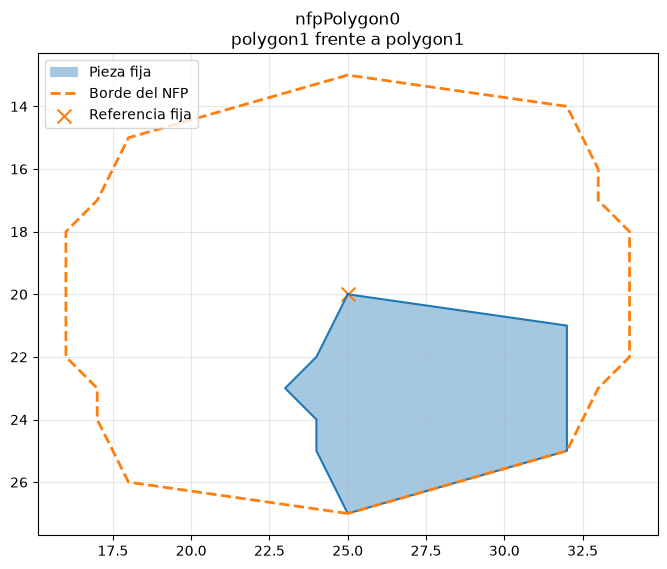

In [168]:
fig, ax = plt.subplots(figsize=(8, 7))

# Pieza fija
static_x, static_y = static_piece.exterior.xy

ax.fill(
    static_x,
    static_y,
    alpha=0.4,
    label="Pieza fija",
)

ax.plot(static_x, static_y)

# NFP absoluto
nfp_x, nfp_y = absolute_nfp.exterior.xy

ax.plot(
    nfp_x,
    nfp_y,
    linestyle="--",
    linewidth=2,
    label="Borde del NFP",
)

# Punto de referencia de la pieza fija
ax.scatter(
    static_reference_x,
    static_reference_y,
    marker="x",
    s=100,
    label="Referencia fija",
)

ax.set_title(
    f"{nfp_geometry_id}\n"
    f"{static_polygon_id} frente a "
    f"{orbiting_polygon_id}"
)

ax.set_aspect("equal")
ax.grid(alpha=0.3)
ax.legend()

# El dataset usa y positivo hacia abajo.
ax.invert_yaxis()

plt.show()

In [169]:
inside_relative = relative_nfp.representative_point()

print(
    "Punto interior relativo:",
    (inside_relative.x, inside_relative.y)
)

print(
    "¿Está dentro?:",
    relative_nfp.contains(inside_relative)
)

Punto interior relativo: (0.0, 0.0)
¿Está dentro?: True


In [170]:
boundary_relative = (
    relative_nfp.boundary.interpolate(
        0.25,
        normalized=True,
    )
)

print(
    "Punto de borde relativo:",
    (boundary_relative.x, boundary_relative.y)
)

print(
    "Distancia al borde:",
    relative_nfp.boundary.distance(
        boundary_relative
    )
)

Punto de borde relativo: (-9.0, 0.39547896129248095)
Distancia al borde: 0.0


In [171]:
min_x, min_y, max_x, max_y = relative_nfp.bounds

outside_relative = Point(
    max_x + 10,
    max_y + 10,
)

print(
    "Punto exterior relativo:",
    (outside_relative.x, outside_relative.y)
)

print(
    "¿Está dentro?:",
    relative_nfp.contains(outside_relative)
)

Punto exterior relativo: (19.0, 17.0)
¿Está dentro?: False


In [172]:
candidate_points_df = pd.DataFrame(
    [
        {
            "caso": "interior",
            "x_relativo": inside_relative.x,
            "y_relativo": inside_relative.y,
            "dentro_nfp": relative_nfp.contains(
                inside_relative
            ),
            "distancia_borde": (
                relative_nfp.boundary.distance(
                    inside_relative
                )
            ),
        },
        {
            "caso": "borde",
            "x_relativo": boundary_relative.x,
            "y_relativo": boundary_relative.y,
            "dentro_nfp": relative_nfp.contains(
                boundary_relative
            ),
            "distancia_borde": (
                relative_nfp.boundary.distance(
                    boundary_relative
                )
            ),
        },
        {
            "caso": "exterior",
            "x_relativo": outside_relative.x,
            "y_relativo": outside_relative.y,
            "dentro_nfp": relative_nfp.contains(
                outside_relative
            ),
            "distancia_borde": (
                relative_nfp.boundary.distance(
                    outside_relative
                )
            ),
        },
    ]
)

candidate_points_df

,caso,x_relativo,y_relativo,dentro_nfp,distancia_borde
0,interior,0.0,0.000000,True,6.730668
1,borde,-9.0,0.395479,False,0.000000
2,exterior,19.0,17.000000,False,16.970563


In [173]:
def relative_to_absolute(
    relative_point: Point,
    reference_x: float,
    reference_y: float,
) -> Point:
    """
    Convierte un desplazamiento relativo en una
    posición absoluta respecto de la pieza fija.
    """

    return Point(
        reference_x + relative_point.x,
        reference_y + relative_point.y,
    )

In [174]:
candidate_reference_points = {
    "interior": relative_to_absolute(
        inside_relative,
        static_reference_x,
        static_reference_y,
    ),
    "borde": relative_to_absolute(
        boundary_relative,
        static_reference_x,
        static_reference_y,
    ),
    "exterior": relative_to_absolute(
        outside_relative,
        static_reference_x,
        static_reference_y,
    ),
}

for case_name, point in candidate_reference_points.items():
    print(
        f"{case_name:>8}: "
        f"({point.x:.3f}, {point.y:.3f})"
    )

interior: (25.000, 20.000)
   borde: (16.000, 20.395)
exterior: (44.000, 37.000)


In [175]:
placed_orbiting_pieces = {}

for case_name, reference_point in (
    candidate_reference_points.items()
):
    placed_orbiting_pieces[case_name] = place_piece(
        polygon_id=orbiting_polygon_id,
        angle=orbiting_angle,
        reference_x=reference_point.x,
        reference_y=reference_point.y,
    )

In [176]:
GEOMETRY_TOLERANCE = 1e-8

In [177]:
def classify_piece_relation(
    piece_a,
    piece_b,
    tolerance: float = GEOMETRY_TOLERANCE,
) -> dict:
    """
    Diferencia entre superposición, contacto y separación.
    """

    intersection = piece_a.intersection(piece_b)

    intersection_area = intersection.area
    distance = piece_a.distance(piece_b)

    if intersection_area > tolerance:
        state = "superposición"

    elif distance <= tolerance:
        state = "contacto"

    else:
        state = "separación"

    return {
        "estado": state,
        "area_interseccion": intersection_area,
        "distancia": distance,
        "tipo_interseccion": intersection.geom_type,
    }

In [178]:
validation_rows = []

for case_name, orbiting_piece in (
    placed_orbiting_pieces.items()
):
    result = classify_piece_relation(
        piece_a=static_piece,
        piece_b=orbiting_piece,
    )

    reference_point = candidate_reference_points[
        case_name
    ]

    validation_rows.append(
        {
            "caso": case_name,
            "referencia_x": reference_point.x,
            "referencia_y": reference_point.y,
            **result,
        }
    )

nfp_validation_df = pd.DataFrame(
    validation_rows
)

nfp_validation_df

,caso,referencia_x,referencia_y,estado,area_interseccion,distancia,tipo_interseccion
0,interior,25.0,20.000000,superposición,44.5,0.000000,Polygon
1,borde,16.0,20.395479,contacto,0.0,0.000000,Point
2,exterior,44.0,37.000000,separación,0.0,16.970563,Polygon


In [179]:
expected_states = {
    "interior": "superposición",
    "borde": "contacto",
    "exterior": "separación",
}

nfp_validation_df["estado_esperado"] = (
    nfp_validation_df["caso"]
    .map(expected_states)
)

nfp_validation_df["coincide"] = (
    nfp_validation_df["estado"]
    == nfp_validation_df["estado_esperado"]
)

nfp_validation_df[
    [
        "caso",
        "estado",
        "estado_esperado",
        "area_interseccion",
        "distancia",
        "coincide",
    ]
]

,caso,estado,estado_esperado,area_interseccion,distancia,coincide
0,interior,superposición,superposición,44.5,0.000000,True
1,borde,contacto,contacto,0.0,0.000000,True
2,exterior,separación,separación,0.0,16.970563,True


In [180]:
def draw_polygon(
    ax,
    polygon,
    label: str,
    alpha: float = 0.35,
):
    """
    Dibuja una geometría poligonal en un eje de Matplotlib.
    """

    x, y = polygon.exterior.xy

    ax.fill(
        x,
        y,
        alpha=alpha,
        label=label,
    )

    ax.plot(x, y)

Figura guardada en:
c:\Users\pc\OneDrive\Escritorio\EIA\AE\reports\figures\validacion_nfp_tres_casos.png


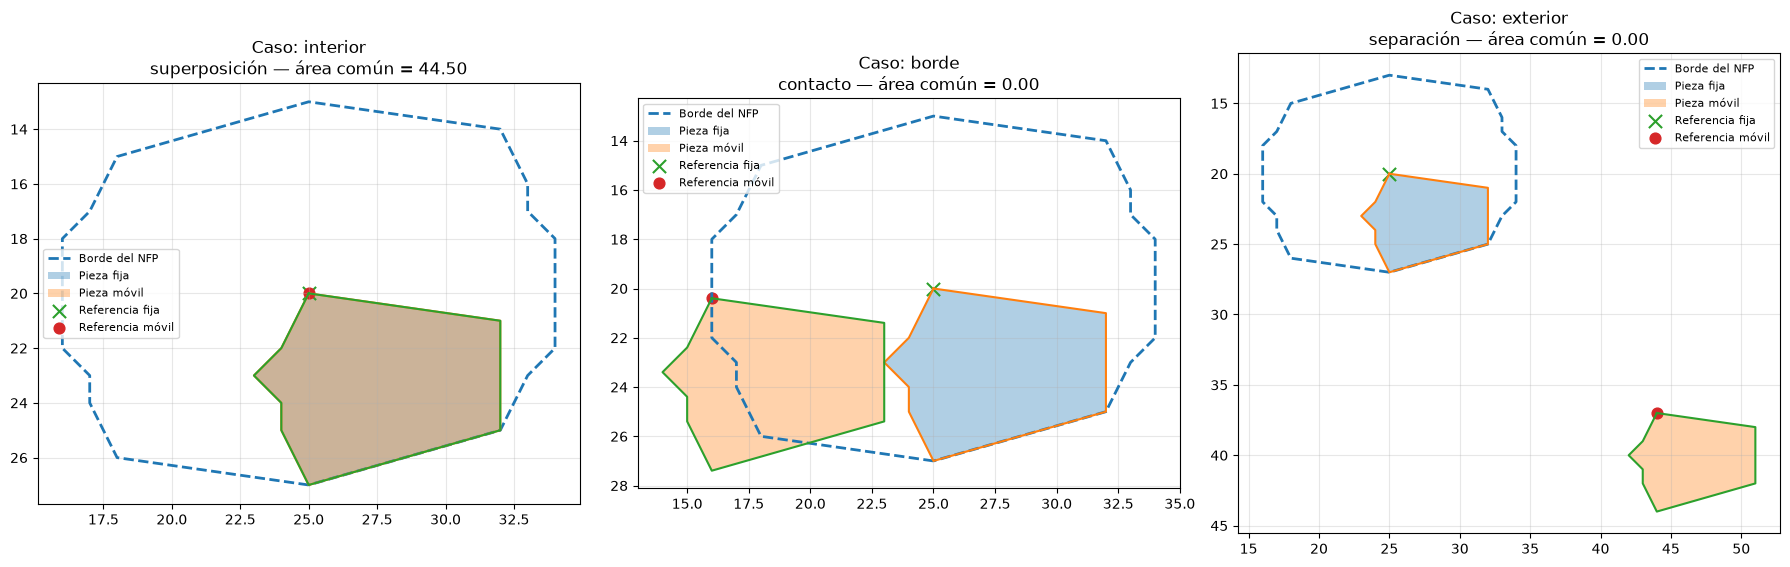

In [182]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6),
)

cases = [
    "interior",
    "borde",
    "exterior",
]

# El NFP absoluto es el mismo en los tres casos.
nfp_x, nfp_y = absolute_nfp.exterior.xy

for ax, case_name in zip(axes, cases):

    orbiting_piece = placed_orbiting_pieces[
        case_name
    ]

    orbiting_reference = candidate_reference_points[
        case_name
    ]

    # Dibujamos el NFP.
    ax.plot(
        nfp_x,
        nfp_y,
        linestyle="--",
        linewidth=2,
        label="Borde del NFP",
    )

    # Dibujamos ambas piezas.
    draw_polygon(
        ax,
        static_piece,
        label="Pieza fija",
    )

    draw_polygon(
        ax,
        orbiting_piece,
        label="Pieza móvil",
    )

    # Referencia de la pieza fija.
    ax.scatter(
        static_reference_x,
        static_reference_y,
        marker="x",
        s=90,
        label="Referencia fija",
    )

    # Referencia de la pieza móvil.
    ax.scatter(
        orbiting_reference.x,
        orbiting_reference.y,
        marker="o",
        s=60,
        label="Referencia móvil",
    )

    # Recuperamos el estado calculado.
    state = nfp_validation_df.loc[
        nfp_validation_df["caso"] == case_name,
        "estado",
    ].iloc[0]

    intersection_area = nfp_validation_df.loc[
        nfp_validation_df["caso"] == case_name,
        "area_interseccion",
    ].iloc[0]

    ax.set_title(
        f"Caso: {case_name}\n"
        f"{state} — área común = "
        f"{intersection_area:.2f}"
    )

    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    # El XML usa el origen arriba a la izquierda.
    ax.invert_yaxis()

FIGURES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

figure_path = (
    FIGURES_DIR
    / "validacion_nfp_tres_casos.png"
)

fig.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

print("Figura guardada en:")
print(figure_path)

plt.tight_layout()
plt.show()

In [183]:
required_ifp_variables = [
    "all_polygons",
    "ifp_relations_df",
    "ifp_lookup",
]

missing_variables = [
    variable_name
    for variable_name in required_ifp_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Faltan variables del bloque anterior: "
        + ", ".join(missing_variables)
    )

print("Relaciones IFP:", len(ifp_relations_df))
print("Entradas en ifp_lookup:", len(ifp_lookup))

Relaciones IFP: 16
Entradas en ifp_lookup: 16


In [184]:
ifp_relations_df["geometry_type"] = (
    ifp_relations_df["ifp_geometry"]
    .map(
        lambda geometry_id: (
            all_polygons[geometry_id]["geometry_type"]
        )
    )
)

ifp_relations_df["geometry_type"].value_counts()

geometry_type
Polygon    16
Name: count, dtype: int64

In [185]:
polygonal_ifp_relations_df = (
    ifp_relations_df[
        ifp_relations_df["geometry_type"] == "Polygon"
    ]
    .reset_index(drop=True)
)

example_ifp_relation = (
    polygonal_ifp_relations_df.iloc[0]
)

example_ifp_relation

relation_index              0
board_polygon        polygon0
board_angle                 0
piece_polygon        polygon1
piece_angle                 0
ifp_geometry      ifpPolygon0
geometry_type         Polygon
Name: 0, dtype: object

In [186]:
board_polygon_id = (
    example_ifp_relation["board_polygon"]
)

piece_polygon_id = (
    example_ifp_relation["piece_polygon"]
)

piece_angle = int(
    example_ifp_relation["piece_angle"]
)

ifp_geometry_id = (
    example_ifp_relation["ifp_geometry"]
)

board_geometry = all_polygons[
    board_polygon_id
]["geometry"]

ifp_geometry = all_polygons[
    ifp_geometry_id
]["geometry"]

print("Tablero:", board_polygon_id)
print("Pieza:", piece_polygon_id)
print("Orientación:", piece_angle)
print("IFP:", ifp_geometry_id)

print("\nLímites del tablero:")
print(board_geometry.bounds)

print("\nLímites del IFP:")
print(ifp_geometry.bounds)

Tablero: polygon0
Pieza: polygon1
Orientación: 0
IFP: ifpPolygon0

Límites del tablero:
(0.0, 0.0, 1000.0, 40.0)

Límites del IFP:
(0.0, 0.0, 991.0, 33.0)


In [187]:
board_polygon_id = (
    example_ifp_relation["board_polygon"]
)

piece_polygon_id = (
    example_ifp_relation["piece_polygon"]
)

piece_angle = int(
    example_ifp_relation["piece_angle"]
)

ifp_geometry_id = (
    example_ifp_relation["ifp_geometry"]
)

board_geometry = all_polygons[
    board_polygon_id
]["geometry"]

ifp_geometry = all_polygons[
    ifp_geometry_id
]["geometry"]

print("Tablero:", board_polygon_id)
print("Pieza:", piece_polygon_id)
print("Orientación:", piece_angle)
print("IFP:", ifp_geometry_id)

print("\nLímites del tablero:")
print(board_geometry.bounds)

print("\nLímites del IFP:")
print(ifp_geometry.bounds)

Tablero: polygon0
Pieza: polygon1
Orientación: 0
IFP: ifpPolygon0

Límites del tablero:
(0.0, 0.0, 1000.0, 40.0)

Límites del IFP:
(0.0, 0.0, 991.0, 33.0)


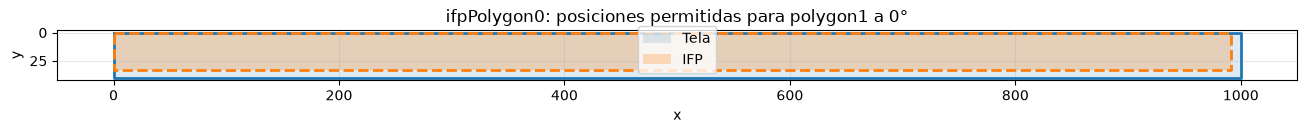

In [188]:
fig, ax = plt.subplots(figsize=(16, 4))

# Tablero
board_x, board_y = board_geometry.exterior.xy

ax.fill(
    board_x,
    board_y,
    alpha=0.15,
    label="Tela",
)

ax.plot(
    board_x,
    board_y,
    linewidth=2,
)

# IFP
ifp_x, ifp_y = ifp_geometry.exterior.xy

ax.fill(
    ifp_x,
    ifp_y,
    alpha=0.25,
    label="IFP",
)

ax.plot(
    ifp_x,
    ifp_y,
    linestyle="--",
    linewidth=2,
)

ax.set_title(
    f"{ifp_geometry_id}: posiciones permitidas para "
    f"{piece_polygon_id} a {piece_angle}°"
)

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_aspect("equal")
ax.grid(alpha=0.3)
ax.legend()

ax.invert_yaxis()

plt.show()

In [189]:
inside_ifp_point = (
    ifp_geometry.representative_point()
)

print(
    "Punto interior:",
    (
        inside_ifp_point.x,
        inside_ifp_point.y,
    )
)

print(
    "¿Está dentro del IFP?:",
    ifp_geometry.contains(inside_ifp_point)
)

Punto interior: (495.5, 16.5)
¿Está dentro del IFP?: True


In [190]:
boundary_ifp_point = (
    ifp_geometry.boundary.interpolate(
        0.20,
        normalized=True,
    )
)

print(
    "Punto sobre el borde:",
    (
        boundary_ifp_point.x,
        boundary_ifp_point.y,
    )
)

print(
    "Distancia al borde:",
    ifp_geometry.boundary.distance(
        boundary_ifp_point
    )
)

Punto sobre el borde: (409.6, 0.0)
Distancia al borde: 0.0


In [191]:
ifp_min_x, ifp_min_y, ifp_max_x, ifp_max_y = (
    ifp_geometry.bounds
)

outside_ifp_point = Point(
    ifp_max_x + 10,
    (ifp_min_y + ifp_max_y) / 2,
)

print(
    "Punto exterior:",
    (
        outside_ifp_point.x,
        outside_ifp_point.y,
    )
)

print(
    "¿Está dentro del IFP?:",
    ifp_geometry.contains(outside_ifp_point)
)

Punto exterior: (1001.0, 16.5)
¿Está dentro del IFP?: False


In [192]:
ifp_candidate_points_df = pd.DataFrame(
    [
        {
            "caso": "interior",
            "reference_x": inside_ifp_point.x,
            "reference_y": inside_ifp_point.y,
            "dentro_ifp": ifp_geometry.contains(
                inside_ifp_point
            ),
            "sobre_borde": (
                ifp_geometry.boundary.distance(
                    inside_ifp_point
                )
                <= 1e-8
            ),
        },
        {
            "caso": "borde",
            "reference_x": boundary_ifp_point.x,
            "reference_y": boundary_ifp_point.y,
            "dentro_ifp": ifp_geometry.contains(
                boundary_ifp_point
            ),
            "sobre_borde": (
                ifp_geometry.boundary.distance(
                    boundary_ifp_point
                )
                <= 1e-8
            ),
        },
        {
            "caso": "exterior",
            "reference_x": outside_ifp_point.x,
            "reference_y": outside_ifp_point.y,
            "dentro_ifp": ifp_geometry.contains(
                outside_ifp_point
            ),
            "sobre_borde": (
                ifp_geometry.boundary.distance(
                    outside_ifp_point
                )
                <= 1e-8
            ),
        },
    ]
)

ifp_candidate_points_df

,caso,reference_x,reference_y,dentro_ifp,sobre_borde
0,interior,495.5,16.5,True,False
1,borde,409.6,0.0,False,True
2,exterior,1001.0,16.5,False,False


In [193]:
ifp_reference_points = {
    "interior": inside_ifp_point,
    "borde": boundary_ifp_point,
    "exterior": outside_ifp_point,
}

ifp_placed_pieces = {}

for case_name, reference_point in (
    ifp_reference_points.items()
):
    ifp_placed_pieces[case_name] = place_piece(
        polygon_id=piece_polygon_id,
        angle=piece_angle,
        reference_x=reference_point.x,
        reference_y=reference_point.y,
    )

In [194]:
def classify_piece_in_board(
    board,
    piece,
    tolerance: float = GEOMETRY_TOLERANCE,
) -> dict:
    """
    Clasifica una pieza respecto del tablero.

    Estados:
    - dentro
    - contacto con borde
    - fuera
    """

    outside_geometry = piece.difference(board)
    outside_area = outside_geometry.area

    is_covered = board.covers(piece)

    distance_to_board_boundary = (
        piece.boundary.distance(
            board.boundary
        )
    )

    if outside_area > tolerance:
        state = "fuera"

    elif (
        is_covered
        and distance_to_board_boundary <= tolerance
    ):
        state = "contacto con borde"

    else:
        state = "dentro"

    return {
        "estado": state,
        "area_fuera": outside_area,
        "cubierta_por_tablero": is_covered,
        "distancia_al_borde": (
            distance_to_board_boundary
        ),
    }

In [196]:
ifp_validation_rows = []

for case_name, placed_piece in (
    ifp_placed_pieces.items()
):
    result = classify_piece_in_board(
        board=board_geometry,
        piece=placed_piece,
    )

    reference_point = ifp_reference_points[
        case_name
    ]

    ifp_validation_rows.append(
        {
            "caso": case_name,
            "reference_x": reference_point.x,
            "reference_y": reference_point.y,
            **result,
        }
    )

ifp_validation_df = pd.DataFrame(
    ifp_validation_rows
)

ifp_validation_df

,caso,reference_x,reference_y,estado,area_fuera,cubierta_por_tablero,distancia_al_borde
0,interior,495.5,16.5,dentro,0.0,True,16.5
1,borde,409.6,0.0,contacto con borde,0.0,True,0.0
2,exterior,1001.0,16.5,fuera,43.5,False,0.0


In [197]:
expected_ifp_states = {
    "interior": "dentro",
    "borde": "contacto con borde",
    "exterior": "fuera",
}

ifp_validation_df["estado_esperado"] = (
    ifp_validation_df["caso"]
    .map(expected_ifp_states)
)

ifp_validation_df["coincide"] = (
    ifp_validation_df["estado"]
    == ifp_validation_df["estado_esperado"]
)

ifp_validation_df[
    [
        "caso",
        "estado",
        "estado_esperado",
        "area_fuera",
        "distancia_al_borde",
        "coincide",
    ]
]

,caso,estado,estado_esperado,area_fuera,distancia_al_borde,coincide
0,interior,dentro,dentro,0.0,16.5,True
1,borde,contacto con borde,contacto con borde,0.0,0.0,True
2,exterior,fuera,fuera,43.5,0.0,True


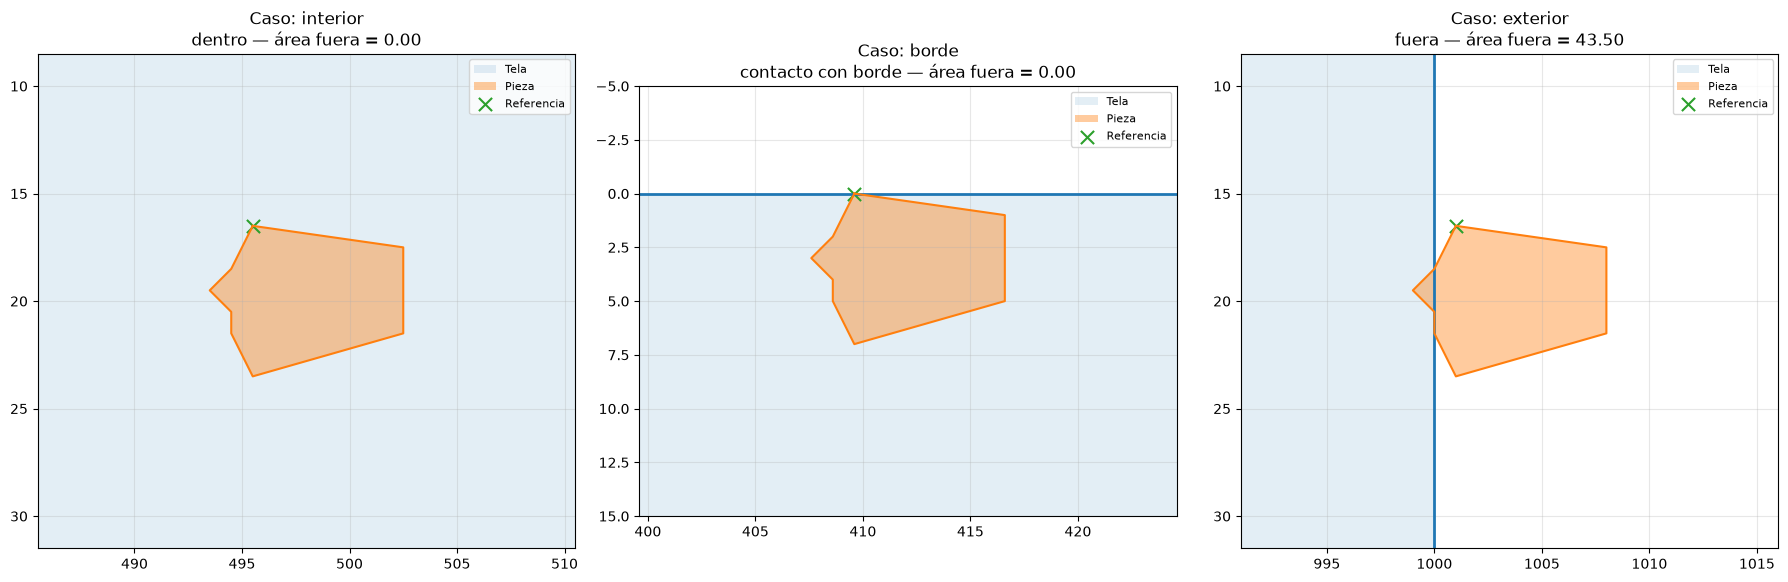

In [198]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6),
)

cases = [
    "interior",
    "borde",
    "exterior",
]

for ax, case_name in zip(axes, cases):
    placed_piece = ifp_placed_pieces[
        case_name
    ]

    reference_point = ifp_reference_points[
        case_name
    ]

    # Tablero completo.
    board_x, board_y = board_geometry.exterior.xy

    ax.fill(
        board_x,
        board_y,
        alpha=0.12,
        label="Tela",
    )

    ax.plot(
        board_x,
        board_y,
        linewidth=2,
    )

    # Pieza.
    piece_x, piece_y = placed_piece.exterior.xy

    ax.fill(
        piece_x,
        piece_y,
        alpha=0.4,
        label="Pieza",
    )

    ax.plot(piece_x, piece_y)

    # Punto de referencia.
    ax.scatter(
        reference_point.x,
        reference_point.y,
        marker="x",
        s=90,
        label="Referencia",
    )

    state = ifp_validation_df.loc[
        ifp_validation_df["caso"] == case_name,
        "estado",
    ].iloc[0]

    outside_area = ifp_validation_df.loc[
        ifp_validation_df["caso"] == case_name,
        "area_fuera",
    ].iloc[0]

    ax.set_title(
        f"Caso: {case_name}\n"
        f"{state} — área fuera = "
        f"{outside_area:.2f}"
    )

    piece_min_x, piece_min_y, piece_max_x, piece_max_y = (
        placed_piece.bounds
    )

    margin = 8

    ax.set_xlim(
        piece_min_x - margin,
        piece_max_x + margin,
    )

    ax.set_ylim(
        max(-5, piece_min_y - margin),
        min(45, piece_max_y + margin),
    )

    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()